# Modelo unidimensional simplificado de escoamento em canal inspirado no Backward-Facing Step via diferenças finitas

O BFS completo é governado por Navier-Stokes 2D. Neste trabalho, considera-se uma região afastada da recirculação, onde o escoamento pode ser aproximado como laminar, permanente e totalmente desenvolvido, reduzindo o problema a uma EDO de segunda ordem para o perfil de velocidade.

## Introdução

A Dinâmica dos Fluidos Computacional (Computational Fluid Dynamics – CFD) constitui uma importante ferramenta para a análise e compreensão de fenômenos de escoamento presentes em diversos problemas de engenharia, como sistemas de transporte de fluidos, máquinas hidráulicas, aerodinâmica e processos industriais. Entre os problemas clássicos de CFD, destaca-se o escoamento em canal com degrau (*Backward-Facing Step* – BFS), amplamente utilizado como benchmark para validação de modelos numéricos devido à presença de fenômenos complexos, como separação da camada limite, recirculação e reanexação do escoamento.

A modelagem completa do problema de BFS é governada pelas equações de Navier-Stokes bidimensionais, cuja resolução numérica exige o emprego de métodos computacionais avançados, como volumes finitos, elementos finitos ou diferenças finitas aplicadas a Equações Diferenciais Parciais (EDPs). Entretanto, para fins didáticos e em conformidade com os objetivos desta atividade, propõe-se a construção de um modelo simplificado, capaz de preservar o contexto físico do problema sem a necessidade de resolver toda a complexidade do escoamento.

Assim, considera-se uma região do canal suficientemente distante da zona de recirculação, na qual o escoamento pode ser aproximado como laminar, permanente, incompressível e totalmente desenvolvido. Sob essas hipóteses, as componentes convectivas tornam-se desprezíveis e o problema reduz-se a uma Equação Diferencial Ordinária (EDO) de segunda ordem que descreve a distribuição de velocidade na direção transversal ao escoamento.

A equação governante simplificada pode ser escrita como:

$$\mu \frac{d^2u}{dy^2}=\frac{dp}{dx}$$

ou, de forma equivalente,

$$\frac{d^2u}{dy^2}=C$$

em que ($u(y)$) representa a velocidade do fluido, ($\mu$) é a viscosidade dinâmica e ($C$) corresponde a um gradiente de pressão constante.

A resolução dessa EDO será realizada por meio do Método das Diferenças Finitas (MDF), uma das técnicas numéricas mais utilizadas para a discretização de equações diferenciais. O método consiste em substituir as derivadas contínuas por aproximações algébricas obtidas a partir de uma malha discreta do domínio, convertendo o problema diferencial em um sistema de equações lineares passível de solução computacional.

Como etapa complementar, propõe-se a organização do desenvolvimento em um pipeline computacional estruturado, contemplando a formulação física do problema, a discretização numérica, a implementação computacional, a validação por meio da solução analítica e a análise de convergência da solução. Essa abordagem permite não apenas o estudo dos fundamentos de métodos numéricos aplicados à mecânica dos fluidos, mas também estabelece uma ponte conceitual com problemas de maior complexidade, como as simulações CFD do *Backward-Facing Step* e as pesquisas em modelagem computacional baseada em física.

## 1. Definição do Problema Físico

Considera-se uma região simplificada do escoamento após o degrau (*Backward-Facing Step* – BFS), suficientemente distante da zona de recirculação, de modo que o escoamento possa ser aproximado como **unidimensional, permanente, incompressível e totalmente desenvolvido**. Nessas condições, admite-se que a componente horizontal da velocidade dependa apenas da coordenada transversal (y), isto é,

$$
u=u(y).
$$

Partindo da equação de quantidade de movimento na direção (x), obtém-se a seguinte relação simplificada:

$$
\mu \frac{d^2u}{dy^2}
=
\frac{dp}{dx},
$$

em que:

* ($\mu$) é a viscosidade dinâmica do fluido;
* ($\frac{dp}{dx}$) representa o gradiente de pressão longitudinal responsável por impulsionar o escoamento.

Dividindo ambos os lados pela viscosidade dinâmica, a equação pode ser escrita na forma:

$$
\frac{d^2u}{dy^2}
=
\frac{1}{\mu}\frac{dp}{dx}
$$

Com o objetivo de introduzir uma distribuição espacial mais rica e produzir perfis de velocidade não estritamente parabólicos, define-se um termo fonte modulado espacialmente:

$$
S_u(y)
=
\frac{1}{\mu}\frac{dp}{dx}f(y),
$$

em que:

$$
f(y)
=
1+\alpha\sin(\pi y),
$$

sendo ($\alpha$) um parâmetro adimensional responsável por controlar a amplitude da perturbação introduzida no escoamento.

Assim, a equação governante adotada neste trabalho é dada por:

$$
\frac{d^2u}{dy^2}
= S_u(y)
$$
$$
\Downarrow
$$
$$
\frac{d^2u}{dy^2}
=
\frac{1}{\mu}\frac{dp}{dx}
\left[
1+\alpha\sin(\pi y)
\right].
$$

Nessa formulação:

* ($u(y)$) é a componente horizontal da velocidade;
* ($S_u(y)$) é o termo fonte associado à distribuição da velocidade;
* ($\mu$) é a viscosidade dinâmica do fluido;
* ($\frac{dp}{dx}$) representa o gradiente de pressão longitudinal;
* ($\frac{1}{\mu}\frac{dp}{dx}$) representa a intensidade média da força motriz do escoamento;
* ($\alpha$) controla a intensidade da perturbação espacial introduzida no problema.

A função

$$
f(y)=1+\alpha\sin(\pi y)
$$

atua como uma **função de modulação espacial suave** do termo fonte, introduzindo variações na intensidade da força motriz ao longo da direção transversal do canal. Seu propósito é representar, de maneira simplificada, a influência de forçamentos espacialmente heterogêneos sobre a distribuição da componente horizontal da velocidade, permitindo a obtenção de perfis não parabólicos e mais próximos de situações de escoamento complexas.

As condições de contorno adotadas são:

$$
u(0)=0,
\qquad
u(H)=0,
$$

as quais representam a condição de não deslizamento (*no-slip*) nas paredes inferior e superior do canal, impondo velocidade nula nas superfícies sólidas que delimitam o escoamento.

## 2. Escolha dos parâmetros

Para obter um perfil positivo de velocidade na direção longitudinal, considera-se um gradiente de pressão negativo, isto é,

$$
\frac{1}{\mu}\frac{dp}{dx}<0
$$

o que representa um escoamento impulsionado por uma queda de pressão ao longo do canal.

Define-se, então, o parâmetro:

$$
C=\frac{1}{\mu}\frac{dp}{dx}
$$

de modo que:

$$
C<0.
$$

Assim, a equação governante pode ser reescrita como:

$$
\frac{d^2u}{dy^2}
=
C\left[1+\alpha\sin(\pi y)\right].
$$

In [2]:
# Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
# Parâmetros do problema
H = 1.0
C = -2.0
alpha = 3.0
N = 10

# Criando malha 1D
dy = H/(N - 1)
y = np.zeros(N)

for i in range(N):
    y[i] = i * dy

print("Malha y:", y)

Malha y: [0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]


## 3. Montar o sistema linear

Para os pontos internos:

$$\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta y^2} = S_u$$

e, multiplicando ambos os lados por $\Delta y²$:

$$u_{i-1} - 2u_i + u_{i+1} = S_u\,\Delta y²$$

## Definindo as matrizes de coeficientes

$$A_{w_i}u_{i-1} + Ap_iu_i + Ae_iu_{i+1} = bi

In [4]:
# Define os coeficientes da equação de diferenças finitas
Aw = np.zeros(N)
Ae = np.zeros(N)
Ap = np.zeros(N)
Su = C*(1 + alpha * np.sin(np.pi * y)) # Termo fonte

# Preenchendo os coeficientes para os nós internos
for i in range(1, N-1):
    Aw[i] = 1/dy**2
    Ae[i] = 1/dy**2
    Ap[i] = -2/dy**2

# Condições de contorno
# No nó 0 (y=0), u(0) = 0
Ap[0] = 1.0
Su[0] = 0.0  # Condição de contorno em y=0
# No nó N-1 (y=H), u(H) = 0
Ap[N-1] = 1.0
Su[-1] = 0.0 # Condição de contorno em y=H

print("Aw:", Aw)
print("Ae:", Ae)
print("Ap:", Ap)
print("Su:", Su)

Aw: [ 0. 81. 81. 81. 81. 81. 81. 81. 81.  0.]
Ae: [ 0. 81. 81. 81. 81. 81. 81. 81. 81.  0.]
Ap: [   1. -162. -162. -162. -162. -162. -162. -162. -162.    1.]
Su: [ 0.         -4.05212086 -5.85672566 -7.19615242 -7.90884652 -7.90884652
 -7.19615242 -5.85672566 -4.05212086  0.        ]


In [5]:
# Matriz do sistema linear
A = np.zeros((N, N))

for i in range(1, N-1):
    A[i, i-1] = Aw[i] # inferior
    A[i, i] = Ap[i]   # diagonal
    A[i, i+1] = Ae[i] # superior
# Condições de contorno
A[0, 0] = Ap[0]
A[N-1, N-1] = Ap[N-1]

print(tabulate(A, tablefmt="fancy_grid"))

╒════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤════╕
│  1 │    0 │    0 │    0 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│ 81 │ -162 │   81 │    0 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │   81 │ -162 │   81 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │    0 │   81 │ -162 │   81 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │    0 │    0 │   81 │ -162 │   81 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │    0 │    0 │    0 │   81 │ -162 │   81 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │    0 │    0 │    0 │    0 │   81 │ -162 │   81 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼

In [6]:
# Resolvendo o sistema linear TDMA
e = np.zeros(N)
b = np.copy(Su)  # Copia do vetor b para modificação durante a eliminação

# TDMA Forward Elimination
for i in range(1, N):
    e[i] = A[i, i-1] / A[i-1, i-1]
    A[i, i] = A[i, i] - e[i] * A[i-1, i]
    b[i] = b[i] - e[i] * b[i-1]
    A[i, i-1] = 0.0  # Elimina o elemento inferior
print("Matriz A após forward elimination:")
print(tabulate(A, tablefmt="fancy_grid"))
print("Vetor b após forward elimination:", b)

# TDMA Back Substitution
u = np.zeros(N)
u[N-1] = b[N-1] / A[N-1, N-1]
for i in range(N-2, -1, -1):
    u[i] = (b[i] - A[i, i+1] * u[i+1]) / A[i, i]
print("Solução numérica u:", u)

Matriz A após forward elimination:
╒═══╤══════╤════════╤══════╤═════════╤═══════╤═══════╤══════════╤═════════╤════╕
│ 1 │    0 │    0   │    0 │    0    │   0   │   0   │   0      │   0     │  0 │
├───┼──────┼────────┼──────┼─────────┼───────┼───────┼──────────┼─────────┼────┤
│ 0 │ -162 │   81   │    0 │    0    │   0   │   0   │   0      │   0     │  0 │
├───┼──────┼────────┼──────┼─────────┼───────┼───────┼──────────┼─────────┼────┤
│ 0 │    0 │ -121.5 │   81 │    0    │   0   │   0   │   0      │   0     │  0 │
├───┼──────┼────────┼──────┼─────────┼───────┼───────┼──────────┼─────────┼────┤
│ 0 │    0 │    0   │ -108 │   81    │   0   │   0   │   0      │   0     │  0 │
├───┼──────┼────────┼──────┼─────────┼───────┼───────┼──────────┼─────────┼────┤
│ 0 │    0 │    0   │    0 │ -101.25 │  81   │   0   │   0      │   0     │  0 │
├───┼──────┼────────┼──────┼─────────┼───────┼───────┼──────────┼─────────┼────┤
│ 0 │    0 │    0   │    0 │    0    │ -97.2 │  81   │   0      │   0     

## 4. Comparar com solução analítica

$$u(y) = \frac{C}{2}(y² - y) - \frac{C\alpha}{\pi²}\sin(\pi y)

In [7]:
u_exact = (C/2) * (y**2 - y) - (C * alpha / np.pi**2) * np.sin(np.pi * y)
print("Solução exata u_exact:", u_exact)

Solução exata u_exact: [0.00000000e+00 3.06688747e-01 5.63607515e-01 7.48702536e-01
 8.45604903e-01 8.45604903e-01 7.48702536e-01 5.63607515e-01
 3.06688747e-01 7.44495979e-17]


## 7. Calcular erros

In [8]:
mae = np.mean(np.abs(u - u_exact))
rmse = np.sqrt(np.mean((u - u_exact)**2))
l2_rel = np.linalg.norm(u - u_exact) / np.linalg.norm(u_exact)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"L2 Relative Error: {l2_rel:.6f}")

MAE: 0.003522
RMSE: 0.004166
L2 Relative Error: 0.007172


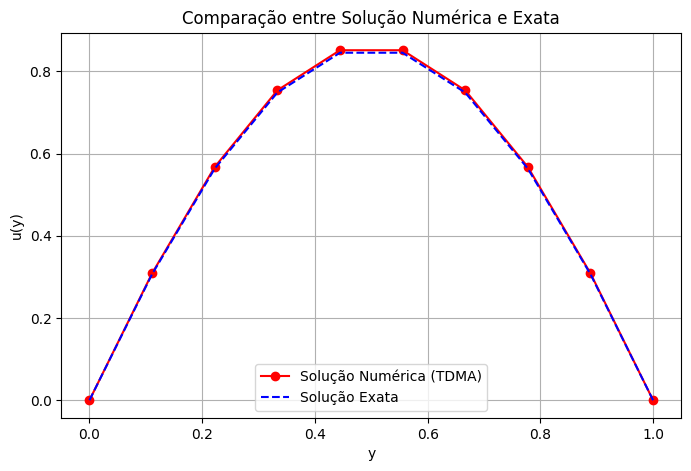

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(y, u, 'ro-', label='Solução Numérica (TDMA)')
plt.plot(y, u_exact, 'b--', label='Solução Exata')
plt.xlabel('y')
plt.ylabel('u(y)')
plt.title('Comparação entre Solução Numérica e Exata')
plt.legend()
plt.grid()
plt.show() 

## Convergência do Método de Diferenças Finitas

In [18]:
# Função para resolver a equação diferencial usando diferenças finitas e TDMA
def u_df(H, C, alpha, N):
    # Criando malha 1D
    dy = H/(N - 1)
    y = np.zeros(N)

    for i in range(N):
        y[i] = i * dy

    print("Malha y:", y)

    # Define os coeficientes da equação de diferenças finitas
    Aw = np.zeros(N)
    Ae = np.zeros(N)
    Ap = np.zeros(N)
    Su = C*(1 + alpha * np.sin(np.pi * y)) # Termo fonte

    # Preenchendo os coeficientes para os nós internos
    for i in range(1, N-1):
        Aw[i] = 1/dy**2
        Ae[i] = 1/dy**2
        Ap[i] = -2/dy**2

    # Condições de contorno
    # No nó 0 (y=0), u(0) = 0
    Ap[0] = 1.0
    Su[0] = 0.0  # Condição de contorno em y=0
    # No nó N-1 (y=H), u(H) = 0
    Ap[N-1] = 1.0
    Su[-1] = 0.0 # Condição de contorno em y=H

    print("Aw:", Aw)
    print("Ae:", Ae)
    print("Ap:", Ap)
    print("Su:", Su)

    # Matriz do sistema linear
    A = np.zeros((N, N))

    for i in range(1, N-1):
        A[i, i-1] = Aw[i] # inferior
        A[i, i] = Ap[i]   # diagonal
        A[i, i+1] = Ae[i] # superior
    # Condições de contorno
    A[0, 0] = Ap[0]
    A[N-1, N-1] = Ap[N-1]

    print(tabulate(A, tablefmt="fancy_grid"))

    # Resolvendo o sistema linear TDMA
    e = np.zeros(N)
    b = np.copy(Su)  # Copia do vetor b para modificação durante a eliminação

    # TDMA Forward Elimination
    for i in range(1, N):
        e[i] = A[i, i-1] / A[i-1, i-1]
        A[i, i] = A[i, i] - e[i] * A[i-1, i]
        b[i] = b[i] - e[i] * b[i-1]
        A[i, i-1] = 0.0  # Elimina o elemento inferior
    print("Matriz A após forward elimination:")
    print(tabulate(A, tablefmt="fancy_grid"))
    print("Vetor b após forward elimination:", b)

    # TDMA Back Substitution
    u = np.zeros(N)
    u[N-1] = b[N-1] / A[N-1, N-1]
    for i in range(N-2, -1, -1):
        u[i] = (b[i] - A[i, i+1] * u[i+1]) / A[i, i]
    print("Solução numérica u:", u)

    # Solução exata
    u_exact = (C/2) * (y**2 - y) - (C * alpha / np.pi**2) * np.sin(np.pi * y)
    print("Solução exata u_exact:", u_exact)
    
    return y, u, u_exact


Malha y: [0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
Aw: [ 0. 81. 81. 81. 81. 81. 81. 81. 81.  0.]
Ae: [ 0. 81. 81. 81. 81. 81. 81. 81. 81.  0.]
Ap: [   1. -162. -162. -162. -162. -162. -162. -162. -162.    1.]
Su: [  0.          -8.84040287 -14.85575219 -19.32050808 -21.69615506
 -21.69615506 -19.32050808 -14.85575219  -8.84040287   0.        ]
╒════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤════╕
│  1 │    0 │    0 │    0 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│ 81 │ -162 │   81 │    0 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │   81 │ -162 │   81 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │    0 │   81 │ -162 │   81 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼─────

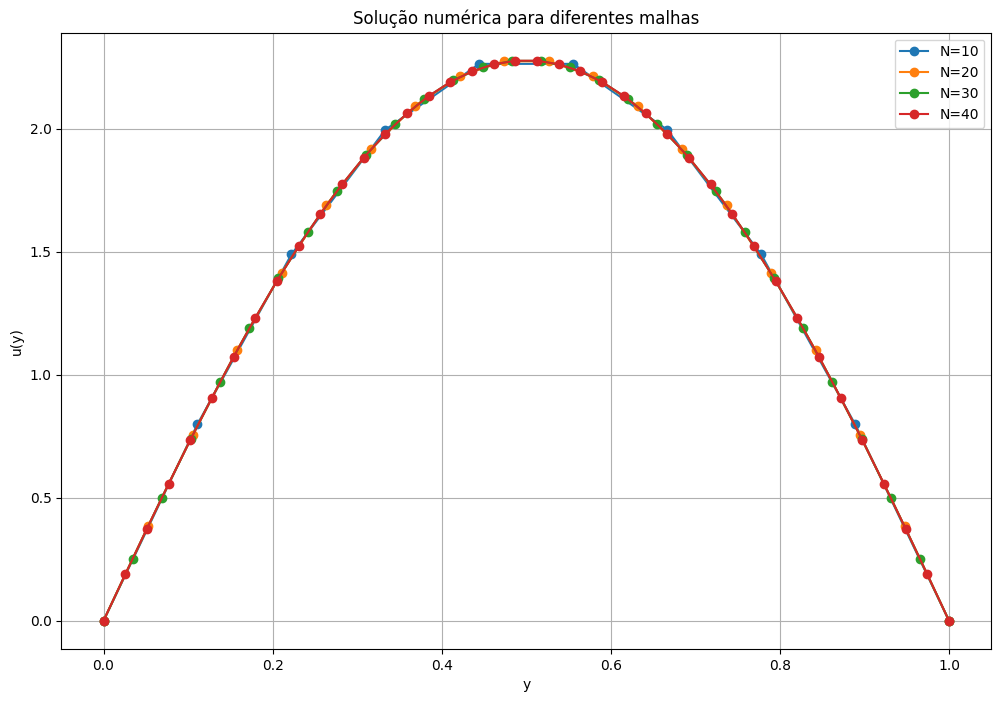

Malha y: [0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
Aw: [ 0. 81. 81. 81. 81. 81. 81. 81. 81.  0.]
Ae: [ 0. 81. 81. 81. 81. 81. 81. 81. 81.  0.]
Ap: [   1. -162. -162. -162. -162. -162. -162. -162. -162.    1.]
Su: [  0.          -8.84040287 -14.85575219 -19.32050808 -21.69615506
 -21.69615506 -19.32050808 -14.85575219  -8.84040287   0.        ]
╒════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤════╕
│  1 │    0 │    0 │    0 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│ 81 │ -162 │   81 │    0 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │   81 │ -162 │   81 │    0 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼────┤
│  0 │    0 │   81 │ -162 │   81 │    0 │    0 │    0 │    0 │  0 │
├────┼──────┼──────┼──────┼──────┼─────

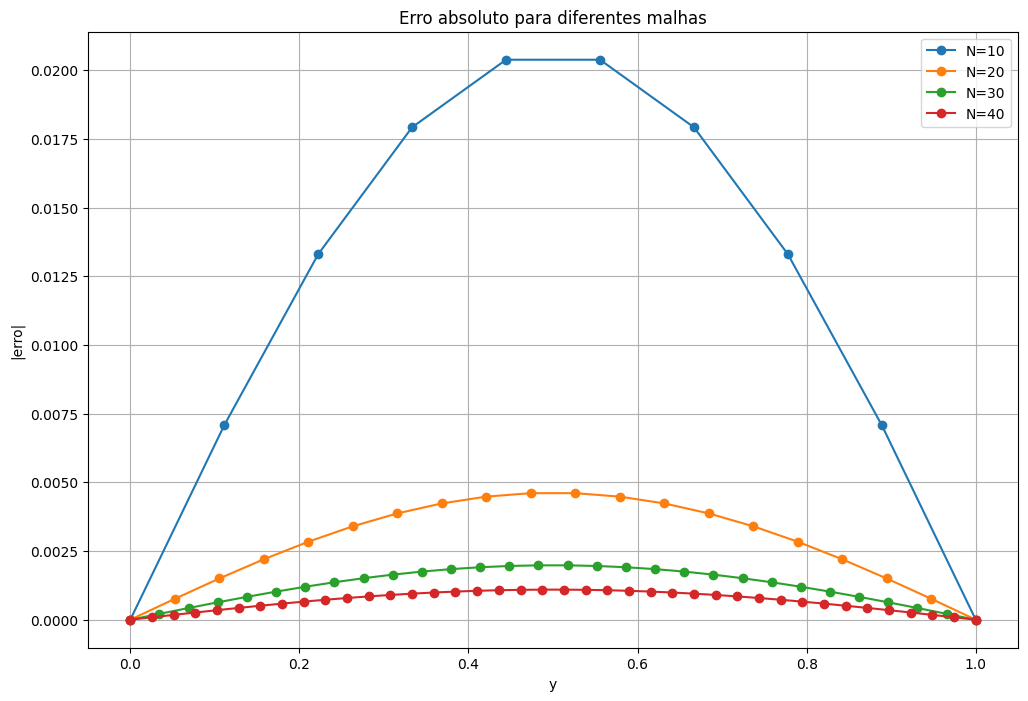

In [24]:
H = 1.0
C = -2.0
alpha = 10.0
N_values = [10, 20, 30, 40]

# Solução numérica para diferentes malhas
plt.figure(figsize=(12, 8))

for n in N_values:
    y, u, u_exact = u_df(H, C, alpha, n)
    plt.plot(y, u, 'o-', label=f'N={n}')

plt.xlabel('y')
plt.ylabel('u(y)')
plt.title('Solução numérica para diferentes malhas')
plt.grid(True)
plt.legend()
plt.show()

# Erro absoluto para diferentes malhas
plt.figure(figsize=(12, 8))

for n in N_values:
    y, u, u_exact = u_df(H, C, alpha, n)
    erro = np.abs(u - u_exact)
    plt.plot(y, erro, 'o-', label=f'N={n}')

plt.xlabel('y')
plt.ylabel('|erro|')
plt.title('Erro absoluto para diferentes malhas')
plt.grid(True)
plt.legend()
plt.show()